In [1]:
# Copyright (C) 2024 Richard Stiskalek
# This program is free software; you can redistribute it and/or modify it
# under the terms of the GNU General Public License as published by the
# Free Software Foundation; either version 3 of the License, or (at your
# option) any later version.
#
# This program is distributed in the hope that it will be useful, but
# WITHOUT ANY WARRANTY; without even the implied warranty of
# MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.  See the GNU General
# Public License for more details.
#
# You should have received a copy of the GNU General Public License along
# with this program; if not, write to the Free Software Foundation, Inc.,
# 51 Franklin Street, Fifth Floor, Boston, MA  02110-1301, USA.
from os.path import exists
import numpy as np
import matplotlib.pyplot as plt
from corner import corner
from getdist import plots
import scienceplots
from os.path import exists
import seaborn as sns


from reconstruction_comparison import *

%load_ext autoreload
%autoreload 2
%matplotlib inline

paths = csiborgtools.read.Paths(**csiborgtools.paths_glamdring)
fdir = "/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity"

## Quick checks

In [ ]:
catalogue = "2MTF"
simname = "IndranilVoidSizeVar_exp"
zcmb_max=0.05
sample_beta = None
no_Vext = True

fname = paths.flow_validation(
    fdir, simname, catalogue, inference_method="mike",
    sample_alpha=False, sample_beta=sample_beta,
    no_Vext=no_Vext, zcmb_max=zcmb_max)


In [ ]:
X = samples_to_getdist(get_samples(fname, False), "Test")
X.updateSettings(settings={'mult_bias_correction_order':2 })

In [ ]:
params = ["void_size", "rLG", "sigma_v"]

# params = ["beta", f"a_{catalogue}", f"b_{catalogue}", f"e_mu_{catalogue}"]
# params = ["Vmag", "l", "b", "sigma_v", "beta", f"mag_cal_{catalogue}", f"alpha_cal_{catalogue}", f"beta_cal_{catalogue}", f"e_mu_{catalogue}"]

with plt.style.context("science"):
    g = plots.get_subplot_plotter()
    g.settings.figure_legend_frame = False
    g.settings.alpha_filled_add = 0.75

    g.triangle_plot(X, params=params, filled=True, legend_loc='upper right')
    
    plt.gcf().suptitle(catalogue_to_pretty(catalogue), y=1.025)
    plt.gcf().tight_layout()
    plt.gcf().show()
    # plt.gcf().savefig(f"../../plots/method_comparison_{simname}_{catalogue}.png", dpi=500, bbox_inches='tight')

In [ ]:
# catalogue = ["LOSS", "Foundation"]
catalogue = "CF4_TFR_i"
simname = "IndranilVoid_exp"
zcmb_max = 0.05
sample_alpha = False

fname = paths.flow_validation(
    fdir, simname, catalogue, inference_method="mike",
    sample_mag_dipole=True,
    sample_beta=False,
    sample_alpha=sample_alpha, zcmb_max=zcmb_max)


samples = get_samples(fname, convert_Vext_to_galactic=True)

samples, labels, keys = samples_for_corner(samples)
fig = corner(samples, labels=labels, show_titles=True,
             title_kwargs={"fontsize": 12}, smooth=1)
# fig.savefig("../../plots/test.png", dpi=250)
fig.show()

In [ ]:
/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoid_exp_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05.hdf5

In [ ]:
/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05.hdf5
no_field 61432.113
/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoid_exp_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05.hdf5
IndranilVoid_exp 61389.203
/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoid_gauss_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05.hdf5
IndranilVoid_gauss 61389.91
/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoid_mb_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05.hdf5
IndranilVoid_mb 61406.324


In [20]:
for simname in ["no_field", "IndranilVoid_exp", "IndranilVoid_gauss", "IndranilVoid_mb"]:
    fname = paths.flow_validation(
        fdir, simname,
        catalogue=['LOSS', 'Foundation', 'CF4_TFR_i', 'CF4_TFR_notSDSS_w1'],
        # catalogue=['LOSS', 'Foundation'],
        inference_method="mike",
        sample_alpha=False, sample_beta=None,
        no_Vext=None,
        # no_Vext=True if "Indranil" in simname else None,
        zcmb_max=0.05, verbose_print=False)
    print(fname)


    print(simname, get_gof("neg_lnZ_harmonic", fname))

/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_no_field_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05.hdf5
no_field 61432.113
/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoid_exp_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05.hdf5
IndranilVoid_exp 61389.203
/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoid_gauss_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05.hdf5
IndranilVoid_gauss 61389.91
/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_IndranilVoid_mb_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05.hdf5
IndranilVoid_mb 61406.324


In [25]:
fname = paths.flow_validation(
    fdir, "Carrick2015",
    catalogue=['LOSS', 'Foundation', 'CF4_TFR_i', 'CF4_TFR_notSDSS_w1'],
    # catalogue=['LOSS', 'Foundation'],
    inference_method="mike",
    sample_alpha=True, sample_beta=None,
    no_Vext=None,
    # no_Vext=True if "Indranil" in simname else None,
    zcmb_max=0.05, verbose_print=False)
print(fname)


print(simname, get_gof("neg_lnZ_harmonic", fname))

/mnt/extraspace/rstiskalek/csiborg_postprocessing/peculiar_velocity/samples_Carrick2015_LOSS_Foundation_CF4_TFR_i_CF4_TFR_notSDSS_w1_mike_zcmb_max_0.05_sample_alpha.hdf5
IndranilVoid_mb 58936.36


## Paper plots

### 1. No $V_{\rm ext}$ and no $\beta$

In [ ]:
# for simname in ["IndranilVoidSizeVar_exp", "IndranilVoidSizeVar_gauss", "IndranilVoidSizeVar_mb"]:
for simname in ["IndranilVoid_exp", "IndranilVoid_gauss", "IndranilVoid_mb"]:
    X = []
    for catalogue in ["2MTF", "SFI_gals", "CF4_TFR_i", "CF4_TFR_w1"]:

        fname = paths.flow_validation(
            fdir, simname, catalogue, inference_method="mike",
            sample_alpha=False, sample_beta=None,
            no_Vext=True, zcmb_max=0.05)

        X_i = samples_to_getdist(get_samples(fname, False), catalogue_to_pretty(catalogue))
        X_i.updateSettings(settings={'mult_bias_correction_order':2 })
        X.append(X_i)

    params = ["rLG", "sigma_v"]
    with plt.style.context("science"):
        g = plots.get_subplot_plotter()
        g.settings.figure_legend_frame = False
        g.settings.alpha_filled_add = 0.75

        g.triangle_plot(X, params=params, filled=True, legend_loc='upper right')
        plt.gcf().suptitle(simname_to_pretty(simname), y=1.025)
        plt.gcf().tight_layout()
        plt.gcf().show()
        plt.gcf().savefig(f"../../plots/void_{simname}_noVext_nobeta.png", dpi=500, bbox_inches='tight')

### 2. No  $V_{\rm ext}$ but sampling $\beta$

In [ ]:
# for simname in ["IndranilVoidSizeVar_exp", "IndranilVoidSizeVar_gauss", "IndranilVoidSizeVar_mb"]:
for simname in ["IndranilVoid_exp", "IndranilVoid_gauss", "IndranilVoid_mb"]:
    X = []
    for catalogue in ["2MTF", "SFI_gals", "CF4_TFR_i", "CF4_TFR_w1"]:

        fname = paths.flow_validation(
            fdir, simname, catalogue, inference_method="mike",
            sample_alpha=False, sample_beta=True,
            no_Vext=True, zcmb_max=0.05)

        X_i = samples_to_getdist(get_samples(fname, False), catalogue_to_pretty(catalogue))
        X.append(X_i)

    params = ["void_size", "rLG", "sigma_v", "beta"]
    with plt.style.context("science"):
        g = plots.get_subplot_plotter()
        g.settings.figure_legend_frame = False
        g.settings.alpha_filled_add = 0.75

        g.triangle_plot(X, params=params, filled=True, legend_loc='upper right')
        plt.gcf().suptitle(simname_to_pretty(simname), y=1.025)
        plt.gcf().tight_layout()
        plt.gcf().show()
        plt.gcf().savefig(f"../../plots/void_{simname}_noVext_beta.png", dpi=500, bbox_inches='tight')

### 3. Yes $V_{\rm ext}$ and no $\beta$ 

In [ ]:
for simname in ["IndranilVoid_exp", "IndranilVoid_gauss", "IndranilVoid_mb"]:
    X = []
    for catalogue in ["2MTF", "SFI_gals", "CF4_TFR_i", "CF4_TFR_w1"]:

        fname = paths.flow_validation(
            fdir, simname, catalogue, inference_method="bayes",
            sample_alpha=False, sample_beta=False,
            no_Vext=None, zcmb_max=0.05)

        X_i = samples_to_getdist(get_samples(fname, False), catalogue_to_pretty(catalogue))
        X.append(X_i)

    params = ["rLG", "sigma_v", "Vx", "Vy", "Vz"]
    with plt.style.context("science"):
        g = plots.get_subplot_plotter()
        g.settings.figure_legend_frame = False
        g.settings.alpha_filled_add = 0.75

        g.triangle_plot(X, params=params, filled=True, legend_loc='upper right')
        plt.gcf().suptitle(simname_to_pretty(simname), y=1.025)
        plt.gcf().tight_layout()
        plt.gcf().show()
        plt.gcf().savefig(f"../../plots/void_{simname}_Vext_nobeta.png", dpi=500, bbox_inches='tight')

### 4. Yes $V_{\rm ext}$ and yes $\beta$

In [ ]:
for simname in ["IndranilVoid_exp", "IndranilVoid_gauss", "IndranilVoid_mb"]:
    X = []
    for catalogue in ["2MTF", "SFI_gals", "CF4_TFR_i", "CF4_TFR_w1"]:

        fname = paths.flow_validation(
            fdir, simname, catalogue, inference_method="bayes",
            sample_alpha=False, sample_beta=True,
            no_Vext=None, zcmb_max=0.05)

        X_i = samples_to_getdist(get_samples(fname, False), catalogue_to_pretty(catalogue))
        X.append(X_i)

    params = ["rLG", "sigma_v", "beta", "Vx", "Vy", "Vz"]
    with plt.style.context("science"):
        g = plots.get_subplot_plotter()
        g.settings.figure_legend_frame = False
        g.settings.alpha_filled_add = 0.75

        g.triangle_plot(X, params=params, filled=True, legend_loc='upper right')
        plt.gcf().suptitle(simname_to_pretty(simname), y=1.025)
        plt.gcf().tight_layout()
        plt.gcf().show()
        plt.gcf().savefig(f"../../plots/void_{simname}_Vext_beta.png", dpi=500, bbox_inches='tight')

###  5. $V_{\rm ext}$ along the model axis and $\beta = 1$

In [ ]:
def profile2vvoid(profile):
    if "mb" in profile:
        return 1586
    elif "gauss" in profile:
        return 2018
    elif "exp" in profile:
        return 2307
    else:
        raise ValueError("Invalid profile")


# for simname in ["IndranilVoidSizeVar_exp", "IndranilVoidSizeVar_gauss", "IndranilVoidSizeVar_mb"]:
for simname in ["IndranilVoid_exp", "IndranilVoid_gauss", "IndranilVoid_mb"]:
    
    X = []
    for catalogue in ["2MTF", "SFI_gals", "CF4_TFR_i", "CF4_TFR_w1"]:

        fname = paths.flow_validation(
            fdir, simname, catalogue, inference_method="mike",
            sample_alpha=False, sample_beta=None,
            no_Vext=True, zcmb_max=0.05, sample_Vmag_vax=True)

        Xi = get_samples(fname, False)
        Xi["Vvoid"] = Xi["Vext_axis_mag"] - profile2vvoid(simname)

        X_i = samples_to_getdist(Xi, catalogue_to_pretty(catalogue))
        X_i.updateSettings(settings={'mult_bias_correction_order':2 })

        X.append(X_i)

    params = ["rLG", "sigma_v", "Vvoid"]
    with plt.style.context("science"):
        g = plots.get_subplot_plotter()
        g.settings.figure_legend_frame = False
        g.settings.alpha_filled_add = 0.75

        g.triangle_plot(X, params=params, filled=True, legend_loc='upper right')
        plt.gcf().suptitle(simname_to_pretty(simname), y=1.025)
        plt.gcf().tight_layout()
        plt.gcf().show()
        plt.gcf().savefig(f"../../plots/void_{simname}_Vext_along_axis_no_beta.png", dpi=500, bbox_inches='tight')

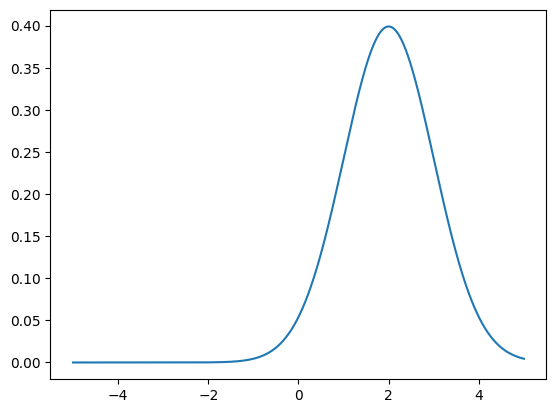

In [ ]:
import numpy as np
from scipy.stats import norm

import matplotlib.pyplot as plt

%matplotlib inline



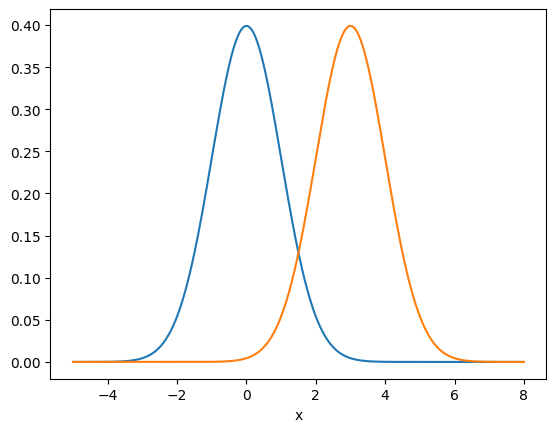

In [ ]:

mu_0 = 0
mu_1 = 3
sigma = 1


x = np.linspace(-5, 8, 1000)
y1 = norm.pdf(x, mu_0, sigma)
y2 = norm.pdf(x, mu_1, sigma)

plt.figure()
plt.plot(x, y1)
plt.plot(x, y2)

plt.xlabel("x")
plt.show()

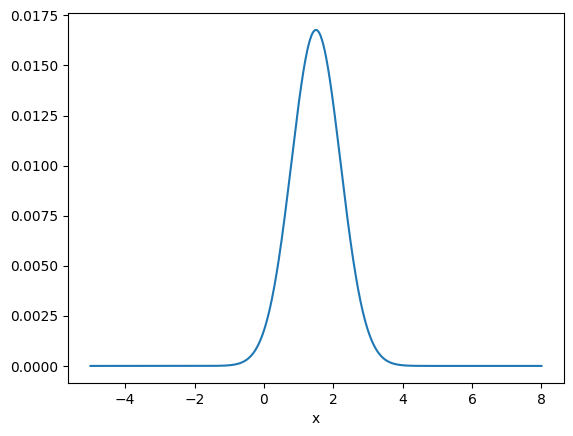

In [32]:
plt.figure()
plt.plot(x, y1 * y2)
# plt.plot(x, y2)

plt.xlabel("x")
plt.show()

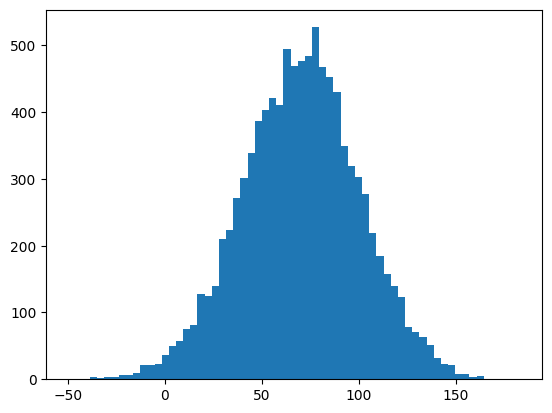

In [34]:
H0 = np.random.normal(70, 30, 10000)


plt.figure()
plt.hist(H0, bins="auto")

plt.show()